In [1]:
import ephem
import datetime
import zoneinfo
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

zoneinfo.available_timezones()

{'Africa/Abidjan',
 'Africa/Accra',
 'Africa/Addis_Ababa',
 'Africa/Algiers',
 'Africa/Asmara',
 'Africa/Asmera',
 'Africa/Bamako',
 'Africa/Bangui',
 'Africa/Banjul',
 'Africa/Bissau',
 'Africa/Blantyre',
 'Africa/Brazzaville',
 'Africa/Bujumbura',
 'Africa/Cairo',
 'Africa/Casablanca',
 'Africa/Ceuta',
 'Africa/Conakry',
 'Africa/Dakar',
 'Africa/Dar_es_Salaam',
 'Africa/Djibouti',
 'Africa/Douala',
 'Africa/El_Aaiun',
 'Africa/Freetown',
 'Africa/Gaborone',
 'Africa/Harare',
 'Africa/Johannesburg',
 'Africa/Juba',
 'Africa/Kampala',
 'Africa/Khartoum',
 'Africa/Kigali',
 'Africa/Kinshasa',
 'Africa/Lagos',
 'Africa/Libreville',
 'Africa/Lome',
 'Africa/Luanda',
 'Africa/Lubumbashi',
 'Africa/Lusaka',
 'Africa/Malabo',
 'Africa/Maputo',
 'Africa/Maseru',
 'Africa/Mbabane',
 'Africa/Mogadishu',
 'Africa/Monrovia',
 'Africa/Nairobi',
 'Africa/Ndjamena',
 'Africa/Niamey',
 'Africa/Nouakchott',
 'Africa/Ouagadougou',
 'Africa/Porto-Novo',
 'Africa/Sao_Tome',
 'Africa/Timbuktu',
 'Africa/

In [2]:
# Demo auto-switch from EST to EDT
mytime = datetime.datetime(2026, 3, 7, 20, 0, tzinfo=zoneinfo.ZoneInfo('America/New_York'))
for _ in range(10):
    mytime += datetime.timedelta(hours=1)
    print(mytime, mytime.tzname())
# "Datetimes constructed in this way are compatible with datetime arithmetic and handle daylight saving time transitions with no further intervention." [https://docs.python.org/3.10/library/zoneinfo.html]

2026-03-07 21:00:00-05:00 EST
2026-03-07 22:00:00-05:00 EST
2026-03-07 23:00:00-05:00 EST
2026-03-08 00:00:00-05:00 EST
2026-03-08 01:00:00-05:00 EST
2026-03-08 02:00:00-05:00 EST
2026-03-08 03:00:00-04:00 EDT
2026-03-08 04:00:00-04:00 EDT
2026-03-08 05:00:00-04:00 EDT
2026-03-08 06:00:00-04:00 EDT


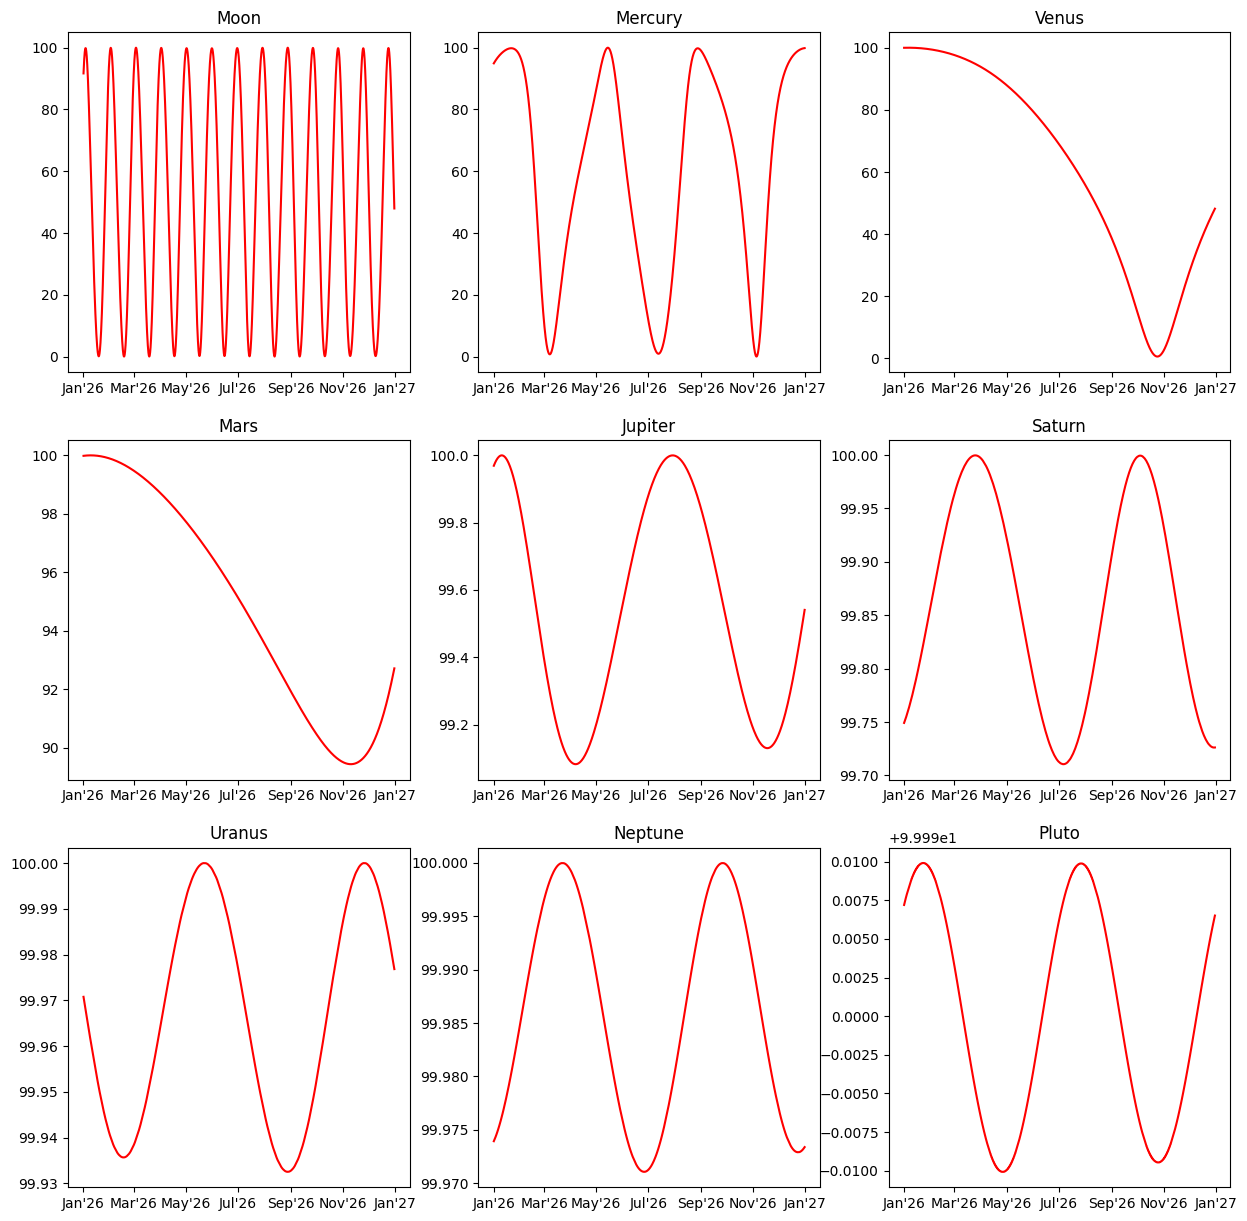

In [3]:
bodies = [ephem.Moon(),
          ephem.Mercury(),
          ephem.Venus(),
          ephem.Mars(),
          ephem.Jupiter(),
          ephem.Saturn(),
          ephem.Uranus(),
          ephem.Neptune(),
          ephem.Pluto()]

fig, ax = plt.subplots(3, 3, figsize=(15, 15))
ax = ax.flatten()
for nbody, body in enumerate(bodies):
    mytime = datetime.datetime(2026, 1, 1, 0, 0)
    date, phase = [], []
    for _ in range(24*364):
        mytime += datetime.timedelta(hours=1)
        body.compute(mytime)
        date.append(mytime)
        phase.append(body.phase)
    ax[nbody].plot(date, phase, color='r')
    ax[nbody].set_title(body.name)
    ax[nbody].axis('tight')
    ax[nbody].xaxis.set_major_formatter(mdates.DateFormatter("%b'%y"))